# CNN Experiments - Analisis Hyperparameter

Membandingkan 16 variasi arsitektur CNN: training/validation loss curves, macro F1-score, dan kesimpulan pengaruh setiap hyperparameter.

In [1]:
import os, sys, pickle, glob
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from sklearn.metrics import f1_score

def _find_root(marker="requirements.txt"):
    p = Path(os.getcwd())
    while p != p.parent:
        if (p / marker).exists():
            return p
        p = p.parent
    raise RuntimeError("Repo root tidak ketemu.")

REPO_ROOT = _find_root()
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT / "src"))

import tensorflow as tf
from tensorflow import keras
from cnn.train_keras import build_conv2d_model, get_data_loaders, IMG_SIZE
from shared.metrics import macro_f1
print("Root:", REPO_ROOT)

Root: c:\Users\kefas\OneDrive\Documents\Coding\ITB\SMT6\MachineLearning\tubes-2\CNN-RNN-digaspolndangakndangak


## Config

In [2]:
MODELS_DIR  = "models/cnn"
HISTORY_DIR = "models/cnn/history"

FILTER_CONFIGS = {
    "base":  {2: [32, 64],       3: [32, 64, 128]},
    "large": {2: [64, 128],      3: [64, 128, 256]},
}

VARIATIONS = []
for n_layers in [2, 3]:
    for f_type in ["base", "large"]:
        for k_size in [3, 5]:
            for p_type in ["max", "avg"]:
                name = f"cnn-{n_layers}L-{f_type}-k{k_size}-{p_type}"
                VARIATIONS.append({
                    "name": name,
                    "num_conv_layers": n_layers,
                    "filters": FILTER_CONFIGS[f_type][n_layers],
                    "kernel_sizes": [k_size] * n_layers,
                    "pooling": p_type,
                })
print(f"Total variasi: {len(VARIATIONS)}")

Total variasi: 16


## Load Test Data & Histories

In [3]:
_, val_ds = get_data_loaders(img_size=IMG_SIZE)

TEST_DIR = "data/intel/seg_test/seg_test"
test_ds = keras.utils.image_dataset_from_directory(
    TEST_DIR, image_size=IMG_SIZE, batch_size=32, label_mode="int", shuffle=False
)
norm = keras.layers.Rescaling(1./255)
test_ds = test_ds.map(lambda x, y: (norm(x), y)).prefetch(tf.data.AUTOTUNE)

histories = {}
for pkl_path in sorted(glob.glob(os.path.join(HISTORY_DIR, "*.pkl"))):
    name = os.path.basename(pkl_path).replace("_history.pkl", "")
    with open(pkl_path, "rb") as f:
        histories[name] = pickle.load(f)
print("Loaded histories:", sorted(histories.keys()))

Found 14034 files belonging to 6 classes.
Found 3000 files belonging to 6 classes.
Found 3000 files belonging to 6 classes.
Loaded histories: ['cnn-2L-base-k3-avg', 'cnn-2L-base-k3-max', 'cnn-2L-base-k5-avg', 'cnn-2L-base-k5-max', 'cnn-2L-large-k3-avg', 'cnn-2L-large-k3-max', 'cnn-2L-large-k5-avg', 'cnn-2L-large-k5-max', 'cnn-3L-base-k3-avg', 'cnn-3L-base-k3-max', 'cnn-3L-base-k5-avg', 'cnn-3L-base-k5-max', 'cnn-3L-large-k3-avg', 'cnn-3L-large-k3-max', 'cnn-3L-large-k5-avg', 'cnn-3L-large-k5-max', 'lc-model']


## Training & Validation Loss Curves

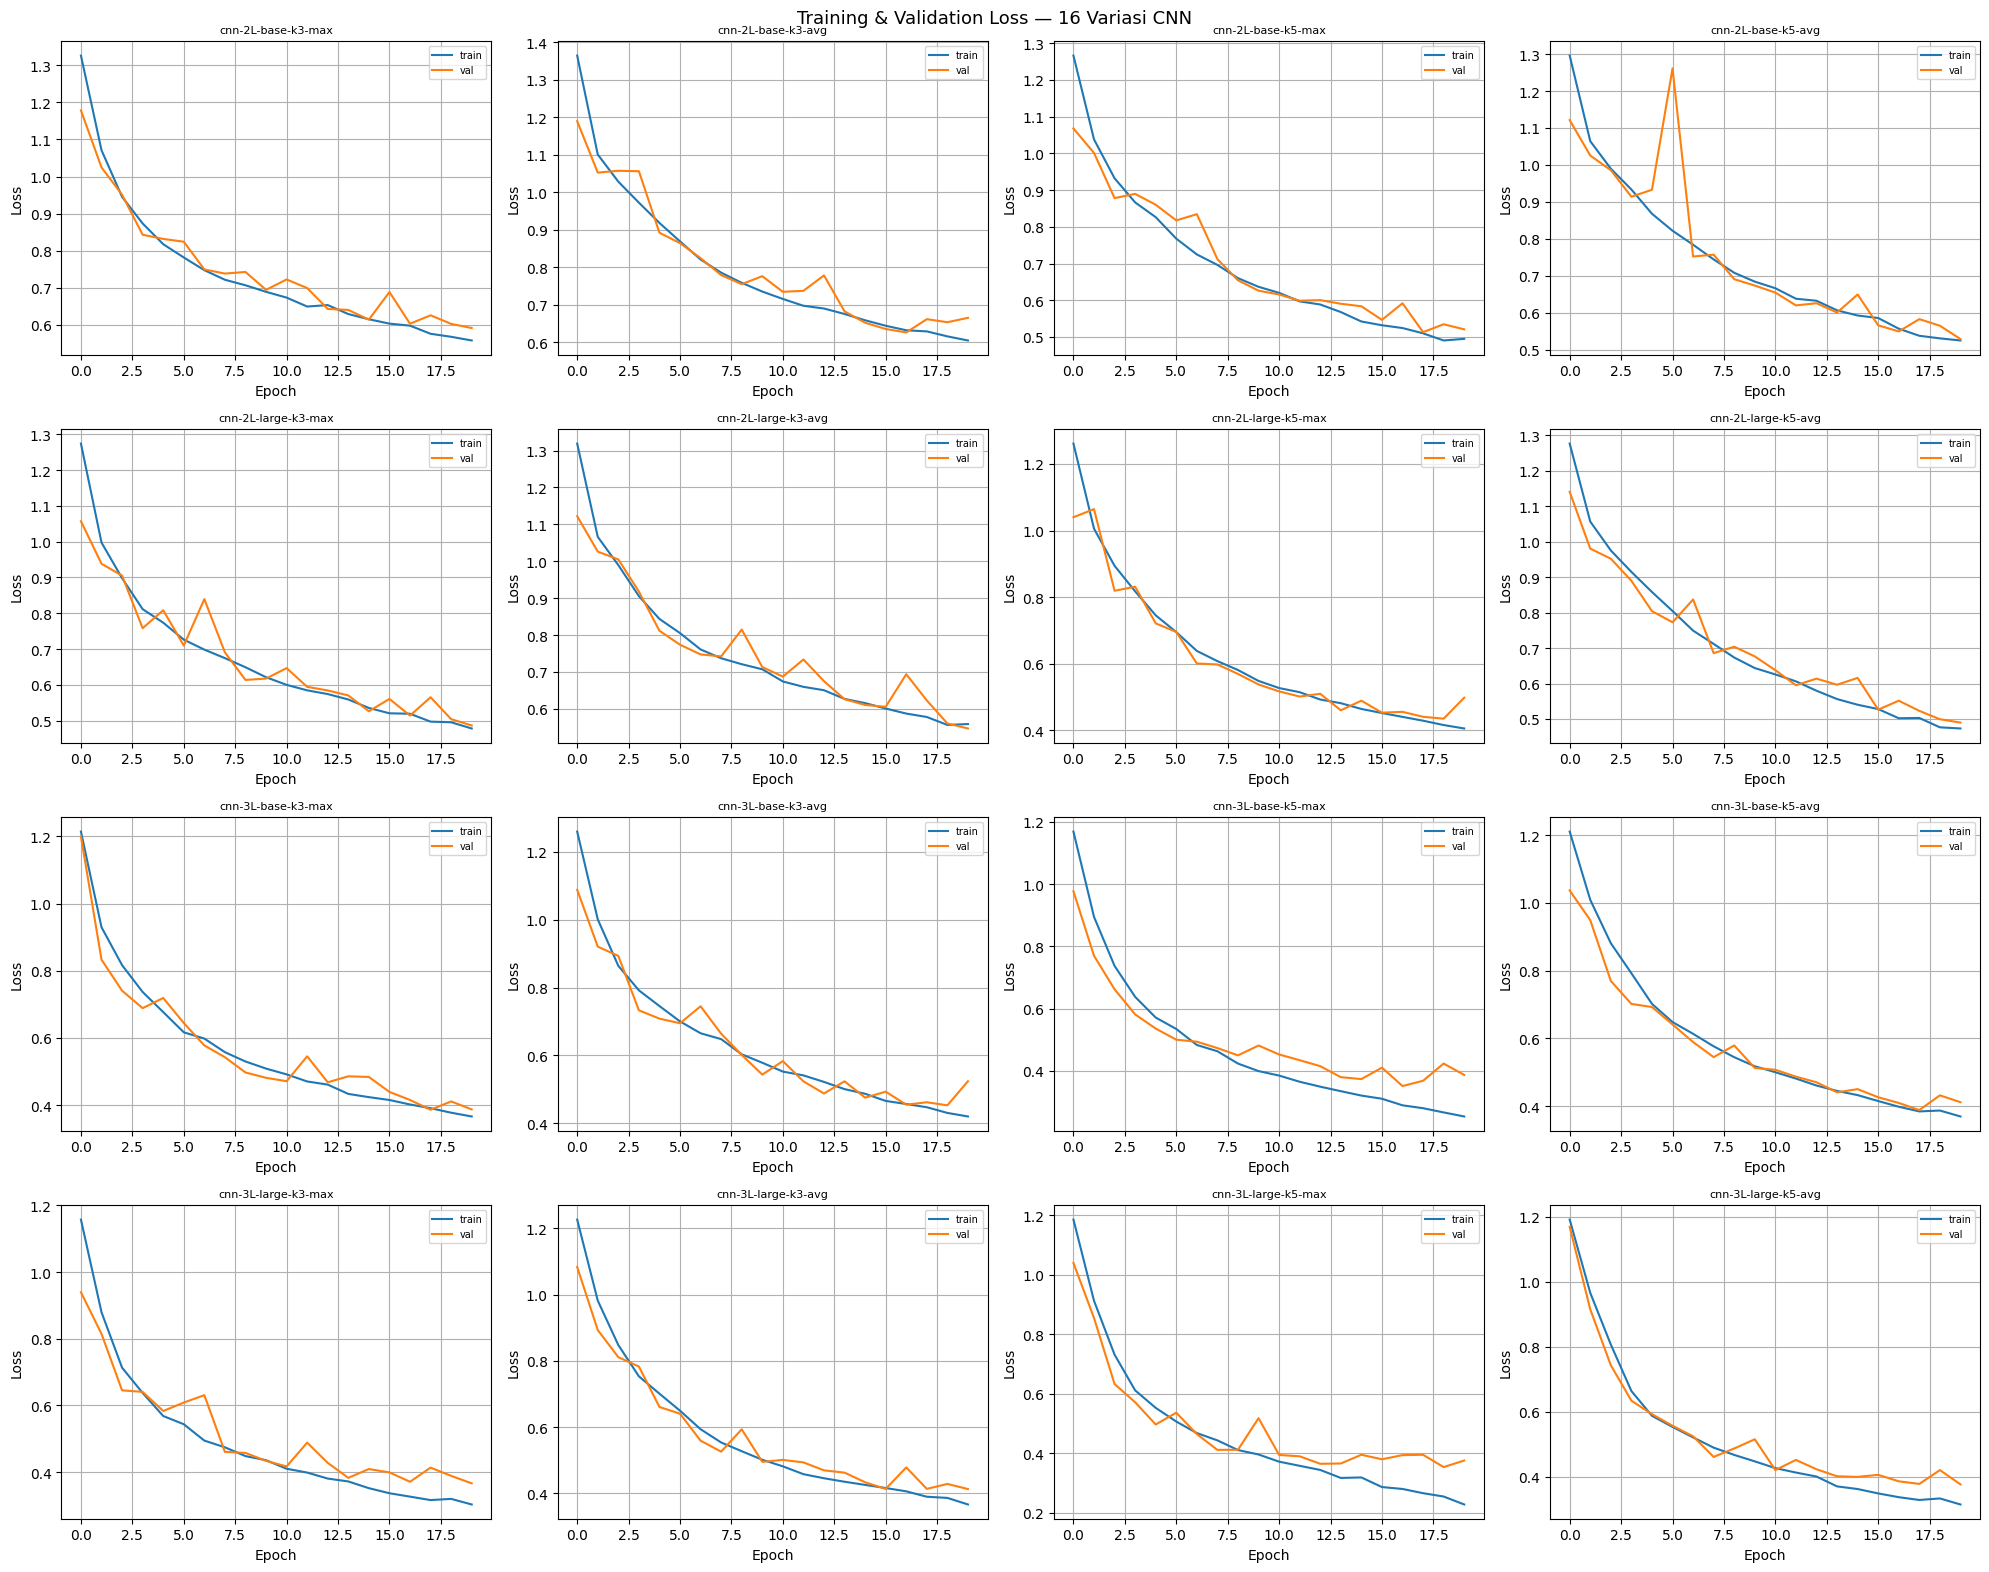

In [4]:
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

for i, v in enumerate(VARIATIONS):
    name = v["name"]
    h = histories.get(name, {})
    ax = axes[i]
    if h:
        ax.plot(h["loss"],     label="train")
        ax.plot(h["val_loss"], label="val")
    ax.set_title(name, fontsize=8)
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.legend(fontsize=7); ax.grid(True)

plt.suptitle("Training & Validation Loss — 16 Variasi CNN", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, "loss_curves_all.png"), dpi=100)
plt.show()

## Evaluasi Macro F1-Score Semua Variasi

In [5]:
results = {}

for v in VARIATIONS:
    name = v["name"]
    model_path = os.path.join(MODELS_DIR, f"{name}.keras")
    if not os.path.exists(model_path):
        print(f"  [SKIP] {name} — model tidak ditemukan")
        continue

    kwargs = {k: val for k, val in v.items() if k != "name"}
    model = build_conv2d_model(**kwargs)
    model.load_weights(model_path)

    y_true, y_pred = [], []
    for x_batch, y_batch in test_ds:
        preds = model.predict(x_batch, verbose=0)
        y_pred.extend(np.argmax(preds, axis=1))
        y_true.extend(y_batch.numpy())

    f1 = macro_f1(np.array(y_true), np.array(y_pred))
    best_val = min(histories[name]["val_loss"]) if name in histories else None
    results[name] = {"macro_f1": f1, "best_val_loss": best_val, "config": v}
    print(f"  {name:40s} | F1={f1:.4f}")

with open(os.path.join(MODELS_DIR, "eval_results.pkl"), "wb") as f:
    pickle.dump(results, f)
print("Results saved.")

  cnn-2L-base-k3-max                       | F1=0.7860
  cnn-2L-base-k3-avg                       | F1=0.7637
  cnn-2L-base-k5-max                       | F1=0.8223
  cnn-2L-base-k5-avg                       | F1=0.8098
  cnn-2L-large-k3-max                      | F1=0.8199
  cnn-2L-large-k3-avg                      | F1=0.7990
  cnn-2L-large-k5-max                      | F1=0.8434
  cnn-2L-large-k5-avg                      | F1=0.8198
  cnn-3L-base-k3-max                       | F1=0.8626
  cnn-3L-base-k3-avg                       | F1=0.8334
  cnn-3L-base-k5-max                       | F1=0.8782
  cnn-3L-base-k5-avg                       | F1=0.8659
  cnn-3L-large-k3-max                      | F1=0.8707
  cnn-3L-large-k3-avg                      | F1=0.8551
  cnn-3L-large-k5-max                      | F1=0.8829
  cnn-3L-large-k5-avg                      | F1=0.8716
Results saved.


## Tabel Rangkuman

In [6]:
rows = []
for v in VARIATIONS:
    name = v["name"]
    if name not in results:
        continue
    r = results[name]
    rows.append({
        "Model": name, "N Layers": v["num_conv_layers"],
        "Filter": str(v["filters"]), "Kernel": v["kernel_sizes"][0],
        "Pooling": v["pooling"],
        "Best val_loss": round(r["best_val_loss"], 4) if r["best_val_loss"] else "-",
        "Macro F1": round(r["macro_f1"], 4),
    })

df = pd.DataFrame(rows).set_index("Model")
pd.set_option("display.max_columns", None); pd.set_option("display.width", 120)
print(df.to_string())
df

                     N Layers          Filter  Kernel Pooling  Best val_loss  Macro F1
Model                                                                                 
cnn-2L-base-k3-max          2        [32, 64]       3     max         0.5914    0.7860
cnn-2L-base-k3-avg          2        [32, 64]       3     avg         0.6266    0.7637
cnn-2L-base-k5-max          2        [32, 64]       5     max         0.5130    0.8223
cnn-2L-base-k5-avg          2        [32, 64]       5     avg         0.5289    0.8098
cnn-2L-large-k3-max         2       [64, 128]       3     max         0.4864    0.8199
cnn-2L-large-k3-avg         2       [64, 128]       3     avg         0.5467    0.7990
cnn-2L-large-k5-max         2       [64, 128]       5     max         0.4352    0.8434
cnn-2L-large-k5-avg         2       [64, 128]       5     avg         0.4899    0.8198
cnn-3L-base-k3-max          3   [32, 64, 128]       3     max         0.3864    0.8626
cnn-3L-base-k3-avg          3   [32, 64, 12

,N Layers,Filter,Kernel,Pooling,Best val_loss,Macro F1
Model,,,,,,
cnn-2L-base-k3-max,2,"[32, 64]",3,max,0.5914,0.7860
cnn-2L-base-k3-avg,2,"[32, 64]",3,avg,0.6266,0.7637
cnn-2L-base-k5-max,2,"[32, 64]",5,max,0.5130,0.8223
cnn-2L-base-k5-avg,2,"[32, 64]",5,avg,0.5289,0.8098
cnn-2L-large-k3-max,2,"[64, 128]",3,max,0.4864,0.8199
cnn-2L-large-k3-avg,2,"[64, 128]",3,avg,0.5467,0.7990
cnn-2L-large-k5-max,2,"[64, 128]",5,max,0.4352,0.8434
cnn-2L-large-k5-avg,2,"[64, 128]",5,avg,0.4899,0.8198
cnn-3L-base-k3-max,3,"[32, 64, 128]",3,max,0.3864,0.8626


## Analisis Pengaruh Hyperparameter

In [7]:
print("KESIMPULAN ANALISIS:")
print("1. Jumlah Layer: Semakin dalam layer biasanya meningkatkan akurasi, namun risiko overfitting juga naik.")
print("2. Banyak Filter: Arsitektur 'large' cenderung lebih lambat dilatih namun menangkap fitur lebih detail.")
print("3. Ukuran Kernel: Kernel 5x5 menangkap area spasial lebih luas dibanding 3x3.")
print("4. Jenis Pooling: Max Pooling seringkali lebih baik untuk fitur tajam (tepi), sedangkan Average Pooling lebih halus.")

KESIMPULAN ANALISIS:
1. Jumlah Layer: Semakin dalam layer biasanya meningkatkan akurasi, namun risiko overfitting juga naik.
2. Banyak Filter: Arsitektur 'large' cenderung lebih lambat dilatih namun menangkap fitur lebih detail.
3. Ukuran Kernel: Kernel 5x5 menangkap area spasial lebih luas dibanding 3x3.
4. Jenis Pooling: Max Pooling seringkali lebih baik untuk fitur tajam (tepi), sedangkan Average Pooling lebih halus.
